## Assignment 4 - Distributed Kalman Filtering

- **Topic:** Distributed state estimation of a target
- **Assessment:** The assignment will be graded according to the grading rubric on Brightspace.


- **Deadline:** 27-03-2026, 17:00
- **Submitting: SUBMIT ONLY `assignment4_groupNumber.ipynb` TO BRIGHTSPACE**. 
where groupNumber is your group number.


## Instructions
**Installation:** 
The virtual environment `venvPSF` has all the necessary packages pre-installed. Make sure to select the virtual environment when running the code. This can be done in the Jupyter notebook (in vscode) by clicking select kernel in the top right, then python environments, then myenv (python 3.11.9).

If you choose to install the virtual environment yourself, the full list of dependencies is in requirements.txt. This can be done using the steps as shown in howToInstallVirtualEnvironments.txt

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `helper.py` and `linAlg.py` and the data file `tracking_data.npz` as this might result in breaking the assignment.


## AI Related Policy
The use of AI is not allowed.


## Information
Please fill in your group number, names and student numbers in the cell below.

In [1]:
# YOUR ANSWER HERE
STUDENT_1_NAME = "Pragun Srivastava"
STUDENT_1_STUDENT_NUMBER = "5542707"

STUDENT_2_NAME = ""
STUDENT_2_STUDENT_NUMBER = ""

### Description and Objectives

The primary objective of this assignment is to estimate the position of a maneuvering target in 2D using a network of anchors. The target is traveling along an unknown trajectory in two dimensions, within the sensing range of the anchors, which have fixed positions. The anchors can measure the radial distance between themselves and the target throughout its journey, with some noise.

We consider a scenario similar to (but not identical to) the figure shown below. In the figure, a network of fixed-position anchors (blue circles) measures the radial distances (red circles) between themselves and the target (represented as a purple triangle). To estimate the target's position the anchors need to communicate with one another, however, they are only allowed to interact with their immediate neighbors in the network as indicated by the gray dashed lines.

The main focus will be to collaboratively estimate the target's position using distributed state estimation, by implementing a distributed Kalman filter formulation.
\
![alt text](multiagent_tracking.png "Title") 

Each anchor is denoted by an integer $n \in \{1, 2, \dots, N\}$ where $N$ is the number of anchors in the network. 
At each time step $k$, anchors measure the squared distance $(d_{n,k})^2 \in \mathbb{R}^+$ between their (fixed) positions $\mathbf{z}_n \in \mathbb{R}^2$ and the target position $\mathbf{p}_k \in \mathbb{R}^2$ as
$$
    d_{n,k} \triangleq ||\mathbf{z}_n - \mathbf{p}_k ||_2.
$$
Unfortunately the measurement model is nonlinear and not suitable for a standard Kalman filter in this form.
We can however, tweak this formulation to obtain a linear form by squaring the distance and expanding the squared norm as
\begin{aligned}
    (d_{n,k})^2 &=  ||\mathbf{z}_n - \mathbf{p}_k ||_2^2 = (\mathbf{z}_n - \mathbf{p}_k)^T (\mathbf{z}_n - \mathbf{p}_k), \\
              &= (\mathbf{z}_n)^T \mathbf{z}_n - 2 (\mathbf{z}_n)^T \mathbf{p}_k + \mathbf{p}_k^T \mathbf{p}_k, \\
    (d_{n,k})^2 - (\mathbf{z}_n)^T \mathbf{z}_n &= - 2 (\mathbf{z}_n)^T \mathbf{p}_k + \mathbf{p}_k^T \mathbf{p}_k, \\
    y_{k,n} &= \tilde{\mathbf{C}}_n \tilde{\mathbf{p}}_k,
\end{aligned}
where $y_{k,n} \triangleq (d_{n,k})^2 - ||\mathbf{z}_n||_2^2, \quad  \tilde{\mathbf{C}}_n \triangleq \begin{bmatrix}  - 2 (\mathbf{z}_n)^T  &  1 \end{bmatrix}, \quad  \tilde{\mathbf{p}}_k \triangleq  \begin{bmatrix} \mathbf{p}_k^T & ||\mathbf{p}_k||_2^2 \end{bmatrix}^T$.
Notice that we added $||\mathbf{p}_k||_2^2$ as a state variable to make this measurement model linear.

To use this approach, let us define the state vector of the target as 
$$ 
\mathbf{x}_k \triangleq \begin{bmatrix} \mathbf{p}_k^T & \dot{\mathbf{p}}_k^T &  ||\mathbf{p}_k||_2^2 \end{bmatrix}^T,
$$
where $ \dot{\mathbf{p}}_k \in \mathbb{R}^2 $ represents the velocity vector.
We can now formulate a state space model to use it for state estimation. 
Denote the state space equations as
\begin{aligned}
    \mathbf{x}_{k+1} &= \mathbf{A} \mathbf{x}_k + \mathbf{w}, \quad \mathbf{w} \sim \mathcal{N}(0, \mathbf{Q}), \\
    y_{k,n} &= \mathbf{C}_n \mathbf{x}_k + v, \quad v \sim \mathcal{N}(0, R),
\end{aligned}
where we choose the dynamic model matrix $\mathbf{A}$ and $\mathbf{C}_n$ as
\begin{aligned}
    \mathbf{A} &\triangleq \text{blkdiag} \biggl( \begin{bmatrix} 1 & \Delta t_k \\ 0 & 1 \end{bmatrix} \otimes \mathbb{I}_2, 1 \biggr), \\
    \mathbf{C}_n &\triangleq \begin{bmatrix}  - 2 (\mathbf{z}_n)^T & 0 & 0 & 1 \end{bmatrix}, \\
\end{aligned}
and $ \Delta t_k $ is the time difference between time step $k+1$ and $k$.

### Provided data
First let us load the simulated data, the data consists of the following elements
- `dt` $\in \mathbb{R}^+$ (float): Time difference between consecutive time steps
- `T` $\in \mathbb{N}$ (int): Number of time steps where time steps $k$ span from $0$ to $T-1$
- `edge_list` (list of tuples): Stores the edges as `(i,j)` which denotes the connection between anchors `i` and `j`.
- `anchor_positions` $\in \mathbb{R}^{2 \times N}$ (numpy array): Horizontally stacked anchor position vectors $[\mathbf{z}_1, \ \mathbf{z}_2, \ \dots, \mathbf{z}_N]$ 
- `measurement_list` $\in \mathbb{R}^{N \times T}$ (numpy array): List of measurements $y_{k,n}$ where `measurement_list[n, k]` denotes the measurement of anchor `n` at time step `k`.
- `true_positions` $\in \mathbb{R}^{2 \times T}$ (numpy array): Horizontally stacked true positions of the target $[\mathbf{p}_0, \ \mathbf{p}_2, \ \dots, \mathbf{p}_{T-1}]$ 

After we load the data, let us see what the anchor network, the ground truth trajectory and measurements look like. Note that the measurements plotted as two dimensional points just for clarity. Actual measurements look more like circles since we only measure the radial distances.

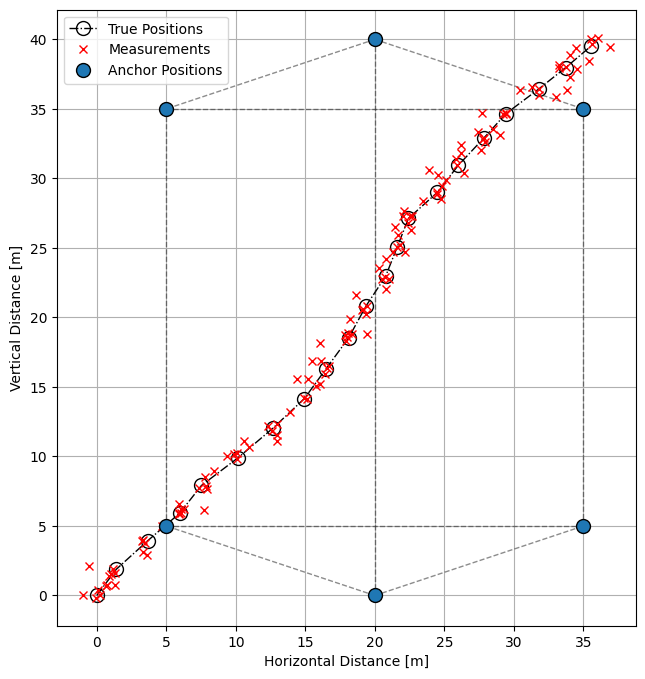

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from linAlg import block_diag
import helper as helper


plt.rcParams.update(
    {
        "lines.linewidth": 1.0,
        "lines.markersize": 10,
        "lines.markeredgewidth": 1.0
        
    }
)
measurement_list, true_states, anchor_positions, edge_list, dt, T, model_parameters = helper.initializeDKFAssignment()

helper.plotMeasurementsAndGroundTruth(true_states, anchor_positions, edge_list, model_parameters)


### Task 1: Construct Matrices
Construct dynamic model matrix $\mathbf{A}$ and measurement model matrices $\mathbf{C}_n$ as described above. 
You can use the parameters `initial_mean` vector,`initial_covariance` matrix, process covariance matrix `Q` and measurement noise variance `R` provided below for the rest of the assignment. 
You can use `block_diag` function to construct $\mathbf{A}$.


### Analysis:
Elaborate on the following:
- Why do we add the new variable $||\mathbf{p}_k||_2^2$ to the state vector? If we wanted to avoid doing this, how would you proceed? 
- Comment on the dynamic update model of the state variable $||\mathbf{p}_k||_2^2$. Does it properly represent the true dynamics? If not, what can be done to mitigate its drawbacks?

**Answer**

- The distance measurement is nonlinear in $\mathbf{p}_k$. Squaring it produces the term $\mathbf{p}_k^T\mathbf{p}_k$, which is still nonlinear. Treating it as an extra state variable, the measurement model becomes linear, allowing use of the linear Kalman filter. To avoid it, you would keep the nonlinear measurement model and use a nonlinear filter, such as an EKF/UKF. 
- No. The model assumes $\|\mathbf{p}_{k+1}\|_2^2 = \|\mathbf{p}_k\|_2^2$, but the true evolution involves cross terms $\mathbf{p}_k^T\dot{\mathbf{p}}_k$ and $\|\dot{\mathbf{p}}_k\|_2^2$, which are nonlinear and can't be captured by $\mathbf{A}$. To compensate, $\mathbf{Q}$ assigns a much larger variance to this component ($Q_{5,5}=100$ vs. $1.5$ and $0.15$ for position/velocity), making the filter rely on measurements rather than the inaccurate prediction to correct this state.

In [3]:
#####  YOUR CODE HERE #####

# Number of anchors
N = anchor_positions.shape[1]

# Construct dynamic model matrix A

kinematic_block = np.array([[1, dt],
                            [0, 1]])
A = block_diag(np.kron(kinematic_block, np.eye(2)), np.array([[1]]))

# Construct measurement model matrices C_n for each anchor

C = np.zeros((N, 1, 5))
for n in range(N):
    z_n = anchor_positions[:, n]
    C[n, 0, :] = np.array([-2*z_n[0], -2*z_n[1], 0, 0, 1])


##### END HERE #####


# Initial Mean and covariance
initial_estimate = np.zeros((5,1))
initial_covariance = np.eye(initial_estimate.shape[0])*100.0

# Process noise covariance (Q) and Measurement noise covariance (R)
Q = np.diag([1.5, 0.15, 1.5, 0.15, 100.0])
R = 0.75


### Task 2: Centralized Kalman Filter Implementation
Implement a centralized version of the Kalman filter by using all measurements generated by the anchors to update the state estimate. After each time step, append your mean and covariance estimates to lists `centralized_means` and `centralized_covariances` respectively.

Note that for the centralized measurement update version you can use an augmented measurement model in the form
\begin{aligned}
    \begin{bmatrix} y_{1,k} \\  y_{2,k} \\ ... \\  y_{N,k} \end{bmatrix} &= \begin{bmatrix} \mathbf{C}_1 \\  \mathbf{C}_2 \\ ... \\  \mathbf{C}_N   \end{bmatrix}  \mathbf{x}_k + \mathbf{v}, \quad \mathbf{v} \sim \mathcal{N}(0, R \ \mathbb{I}_N).
\end{aligned}

### Analysis:
Elaborate on the following:
- Comment on the centralized Kalman filter mean estimates. Explain how $||\mathbf{p}_k||_2^2$ is estimated without even measuring the variable itself.

The CKF tracks position well since all $N$ anchors contribute measurements at every step, giving redundant information in the position-related components. The variable $\|\mathbf{p}_k\|_2^2$ is never measured directly (no sensor outputs it). However, it is estimated because it appears in the state vector and every measurement $y_{n,k}$ depends on it through the last column of $\mathbf{C}_n$ (which is $1$). So each anchor's measurement contains implicit information about $\|\mathbf{p}_k\|_2^2$, and the Kalman gain propagates this into the estimate. Once $\mathbf{p}_k$ is well estimated, $\|\mathbf{p}_k\|_2^2$ is constrained by consistency with the position estimates and the measurements.


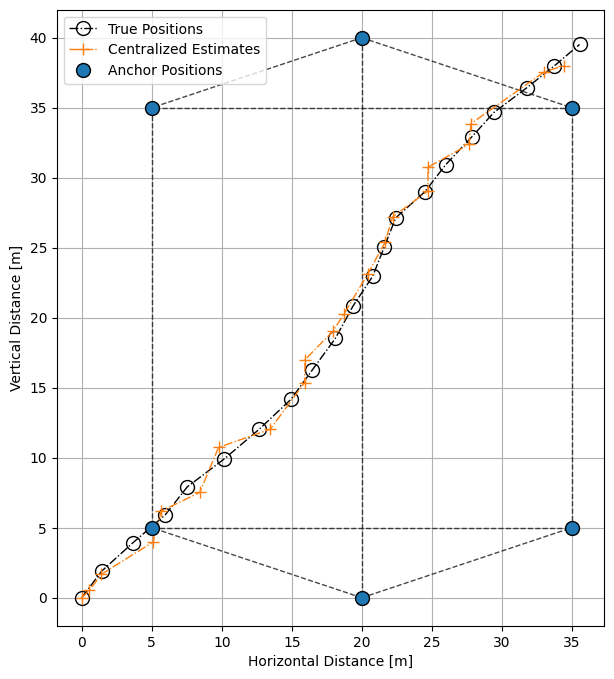

In [4]:
# Centralized estimates
centralized_means = [initial_estimate]
centralized_covariances = [initial_covariance]


#####  YOUR CODE HERE #####

# Stack all C_n into one big measurement matrix
C_full = np.vstack([C[n] for n in range(N)])

# Measurement noise covariance
R_full = R * np.eye(N)

for k in range(T):
    # Previous estimates
    x_prev = centralized_means[-1]
    P_prev = centralized_covariances[-1]

    # Prediction
    x_pred = A @ x_prev
    P_pred = A @ P_prev @ A.T + Q

    # Stack measurements from all anchors at time step k
    y_k = measurement_list[:, k].reshape(-1, 1)  

    # Innovation
    S_k = C_full @ P_pred @ C_full.T + R_full
    K_k = P_pred @ C_full.T @ np.linalg.inv(S_k)

    # Correction
    x_corr = x_pred + K_k @ (y_k - C_full @ x_pred)
    P_corr = P_pred - K_k @ C_full @ P_pred

    centralized_means.append(x_corr)
    centralized_covariances.append(P_corr)

##### END HERE #####


helper.plotCentralizedKFEstimate(true_states, anchor_positions, edge_list, centralized_means)

### Task 3: Distributed Kalman Filter Implementation
Implement a distributed Kalman filter using the formulation given below. After each time step, append your mean and covariance estimates for anchor `n` to lists `local_means[n]` and `local_covariances[n]` respectively.




Assume that anchor $n$ has access to measurements of itself and its neighbors $j \in \mathcal{N}_n \cup \{n\}$.
At time $k$, a local estimate can be computed using the following procedure:

\begin{aligned}
&\text{Time Update:} \\
&\hat{x}_{n, k+1 | k} = A \hat{x}_{n, k+1 | k}  \\
&P_{n, k+1 | k} = A P_{n, k+1 | k} A^T + Q  \\
\newline
&\text{Measurement Update:} \\
&x_{n,k} = \hat{x}_{n, k | k-1} \\
&P_{n,k} = P_{n, k | k-1} \\
&\text{For each} \ j \in \mathcal{N}_n \cup \{n\} \ \text{repeat:} \\
& \quad S_{j,k} = C_{j} P_{n,k} C_{j}^T + R_{j} \\
& \quad K_{j,k} = P_{n,k} C_{j}^T S_{j,k}^{-1} \\
& \quad x_{n,k} = x_{n,k} + K_{j,k} (y_{j,k} - C_{j} x_{n,k})\\
& \quad P_{n,k} = P_{n,k} - K_{j,k}  C_{j}  P_{n,k} \\
&\text{end} \\
&\hat{x}_{n, k | k} = x_{n,k} \\
&P_{n, k | k} = P_{n,k} \\
\end{aligned}

Alternatively a more compact from  can be expressed, similar to the information form KF, as
\begin{aligned}
&\text{Time Update:} \\
&\hat{x}_{n, k+1 | k} = A \hat{x}_{n, k | k}  \\
&P_{n, k+1 | k} = A P_{n, k | k} A^T + Q  \\
\newline
&\text{Measurement Update:} \\
&P_{n,k | k}^{-1} = P_{n,k | k-1}^{-1} + \sum_{j \in \mathcal{N}_n \cup \{n\}} C_{j}^T  R_{j}^{-1}  C_{j}  \\
&\hat{x}_{n, k | k} = \hat{x}_{n,k | k-1} + P_{n,k|k} \sum_{j \in \mathcal{N}_n \cup \{n\}} C_{j}^T R_{j}^{-1} (y_{j, k} - C_{j}\hat{x}_{n,k | k-1}  )\\
\end{aligned}

### Analysis:
Elaborate on the following:
- Analyze the behavior of the decentralized Kalman filter. At a glance, how does it differ from the centralized one?
- How would the estimates change if you change the number of edges. Comment on what would happen if all edges were removed.
- How many neighbors does an anchor need for a feasible solution? In other words, how many neighbors are required for each anchor to estimate a position? You may provide a geometric interpretation.

**Answer**

- Each node's estimate is noisier than the CKF since it only uses measurements from itself and its neighbours, not all $N$ anchors. Different nodes produce different estimates depending on their neighborhood, whereas the CKF produces a single global estimate. 
- More edges means each node accesses more measurements, improving estimates and bringing them closer to the CKF. Fewer edges worsens performance. If all edges are removed, each node only uses its own single measurement per step, which is not enough to observe the full 5D state. Hence, the filter would likely diverge or perform poorly.
- Each anchor provides one scalar measurement involving position and $\|\mathbf{p}_k\|_2^2$. The state has 5 components, but velocity is only observable through the dynamics over time, leaving 3 spatial unknowns ($p_x, p_y, \|\mathbf{p}_k\|_2^2$) that need measurements. Each measurement from a distinct anchor gives one constraint. So a node needs at least 2 neighbors (plus itself = 3 anchors total). 

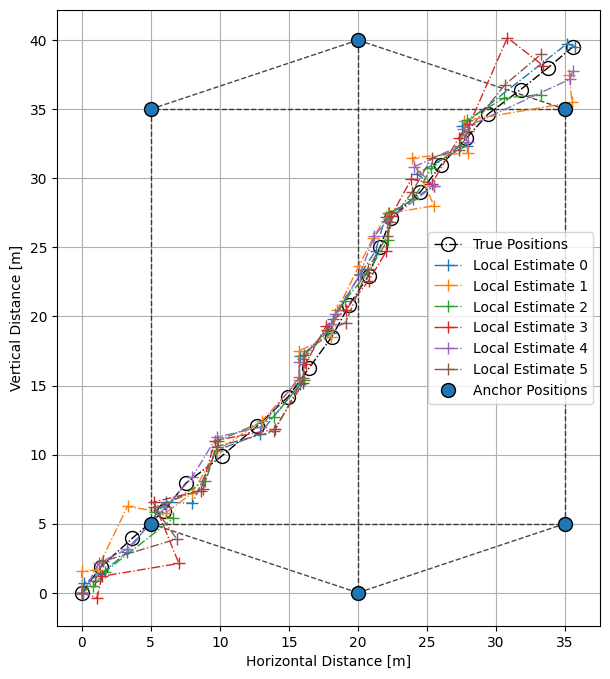

In [5]:
# Initialize per anchor variables
local_means = [[initial_estimate] for _ in range(anchor_positions.shape[1])]
local_covariances = [[initial_covariance] for _ in range(anchor_positions.shape[1])]

#### YOUR CODE HERE ####

# Build neighbor dictionary from edge_list
neighbors = {n: set() for n in range(N)}
for (i, j) in edge_list:
    neighbors[i].add(j)
    neighbors[j].add(i)

for k in range(T):
    for n in range(N):
        x_prev = local_means[n][-1]
        P_prev = local_covariances[n][-1]

        # Prediction
        x_pred = A @ x_prev
        P_pred = A @ P_prev @ A.T + Q

        # Measurement update
        x_n = x_pred.copy()
        P_n = P_pred.copy()

        for j in list(neighbors[n]) + [n]:
            C_j = C[j]              
            y_j = measurement_list[j, k].reshape(-1, 1)  

            S_j = C_j @ P_n @ C_j.T + R 
            K_j = P_n @ C_j.T / S_j        

            x_n = x_n + K_j @ (y_j - C_j @ x_n)
            P_n = P_n - K_j @ C_j @ P_n

        local_means[n].append(x_n)
        local_covariances[n].append(P_n)


#### END HERE ####

helper.plotDecentralizedKFEstimate(true_states, anchor_positions, edge_list, local_means)



### Task 4: Comparison
Compute the squared errors of the centralized and local position mean estimates and plot them against time instances. Make sure that the axes are labeled with appropriate units. Also include a legend with descriptive names for each estimate.

### Analysis:
- Compare and discuss the filter performances. 
- What are the main advantages and disadvantages of centralized and decentralized Kalman filters?

**Answer**

- The CKF consistently has the lowest error across all time steps as it fuses all 6 anchor measurements simultaneously. The local filters show higher and more variable errors with spikes at k = 2 and k = 18 where some nodes reach errors beyond 15. Well connected nodes (e.g. node 1, node 5) stay closer to the CKF, while less connected nodes (e.g. node 4) show the most dramatic deviations. In calmer regions such as k = 12-14, all filters converge to similar low errors. This indicates that the target trajectory is easier to track at these time steps. 
- CKF leads to optimal estimation performance since it uses all measurements. However, it requires all data to be sent to a centralized location, meaning communication between nodes is required. The additional processing also makes CKF more computationally expensive, especially as N grows. DKF (LKF-II) is advantageous as it does not rely on communication between nodes, and is also less computationally expensive. However, the downside is that the estimates are supoptimal as each node only sees a subset of measurements. This leads to higher errors overall, as well as disagreement between nodes, which could be interpreted as higher uncertainty.

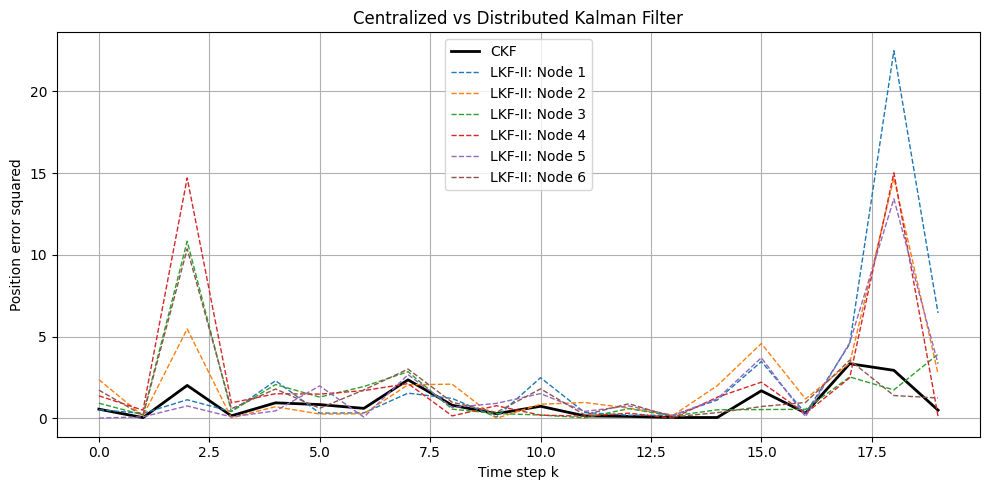

In [6]:
#### YOUR CODE HERE ####

# Compute squared position errors

centralized_se = np.zeros(T)
local_se = {n: np.zeros(T) for n in range(N)}

for k in range(T):
    p_true = true_states[:2, k].reshape(-1, 1) 

    p_ckf = centralized_means[k + 1][:2]
    centralized_se[k] = np.sum((p_true - p_ckf) ** 2)

    for n in range(N):
        p_local = local_means[n][k + 1][:2]
        local_se[n][k] = np.sum((p_true - p_local) ** 2)

# Plot

time_steps = np.arange(T)

plt.figure(figsize=(10, 5))
plt.plot(time_steps, centralized_se, 'k-', linewidth=2, label='CKF')
for n in range(N):
    plt.plot(time_steps, local_se[n], '--', label=f'LKF-II: Node {n+1}')

plt.xlabel('Time step k')
plt.ylabel('Position error squared')
plt.title('Centralized vs Distributed Kalman Filter')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### END HERE ####

#### Feedback:
Please use this markdown to share any comments, suggestions, or errors you encountered in the assignment. Your feedback will help us to improve it for future years.